# Chapter 1: Understanding the data.

The dataset used here (you can find more information about it [here](https://www.dws.gov.za/iwqs/wms/data/A21/A21_90214.png)) is one of multiple datasets that we will use to understand our data, and build our models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## Loading and cleaning the data

In [3]:
df = pd.read_csv('../.data/A21_90214.csv')
df.replace('#n/a', np.nan, inplace=True)
df['date_time'] = pd.to_datetime(df['date_time'])
cols_to_exclude = ['mon_feature_id', 'date_time', 'sample_begin_depth', 'institution_abbr', 'preservative_abbr', 'Station', 'Qat']

measurement_cols = [col for col in df.columns if col not in cols_to_exclude]

for col in measurement_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values('date_time').reset_index(drop=True)
print(f"Data cleaned! Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

Data cleaned! Dataset contains 797 rows and 41 columns.



In [4]:
df = df.sort_values('date_time').reset_index(drop=True)

# Output the results of the cleaning the data
print("CLEANED INFO:")
print(df.info())
print("\nMISSING VALUES SUMMARY (Top 5):")
print(df[measurement_cols].isna().sum().sort_values(ascending=False).head(5))

CLEANED INFO:
<class 'pandas.DataFrame'>
RangeIndex: 797 entries, 0 to 796
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   mon_feature_id           797 non-null    int64         
 1   date_time                797 non-null    datetime64[us]
 2   sample_begin_depth       789 non-null    str           
 3   institution_abbr         797 non-null    str           
 4   preservative_abbr        797 non-null    str           
 5   Ca_Diss_Water            771 non-null    float64       
 6   Ca_Diss_Water_dl         769 non-null    float64       
 7   Cl_Diss_Water            780 non-null    float64       
 8   Cl_Diss_Water_dl         778 non-null    float64       
 9   DMS_Tot_Water            678 non-null    float64       
 10  DMS_Tot_Water_dl         304 non-null    float64       
 11  EC_Phys_Water            786 non-null    float64       
 12  EC_Phys_Water_dl         786 non-

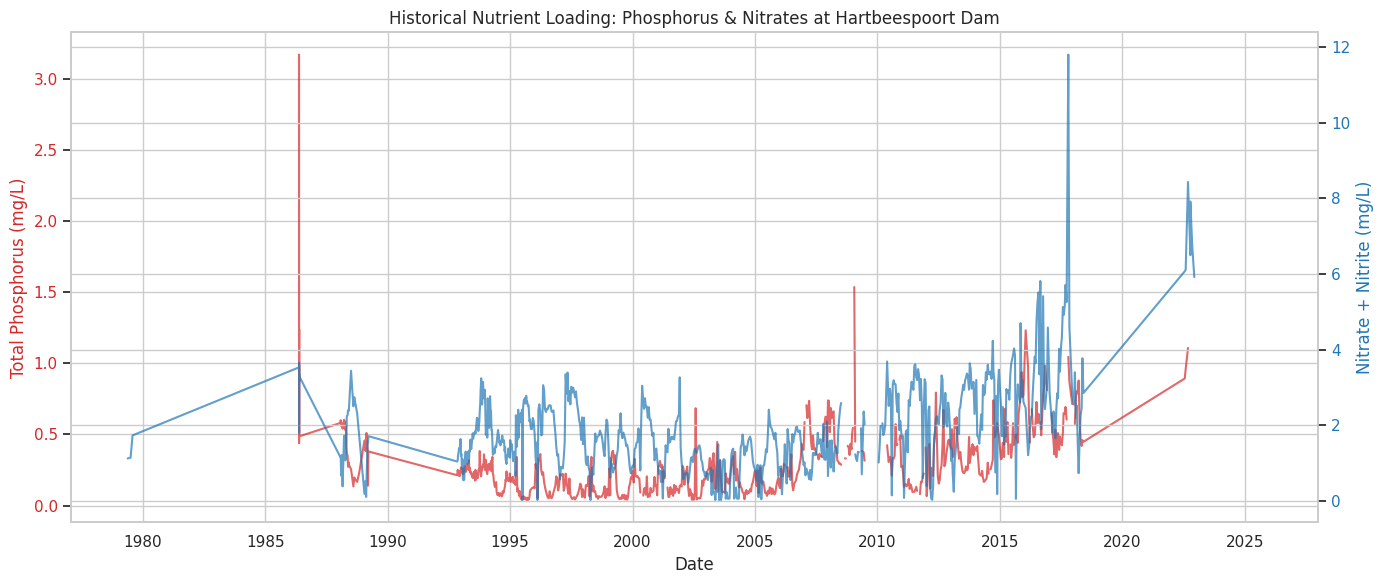

In [5]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Phosphorus (mg/L)', color=color)
ax1.plot(df['date_time'], df['P_Tot_Water'], color=color, alpha=0.7, label='Total Phosphorus')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Nitrate + Nitrite (mg/L)', color=color)
ax2.plot(df['date_time'], df['NO3_NO2_N_Diss_Water'], color=color, alpha=0.7, label='Nitrates')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Historical Nutrient Loading: Phosphorus & Nitrates at Hartbeespoort Dam')
fig.tight_layout()
plt.show()

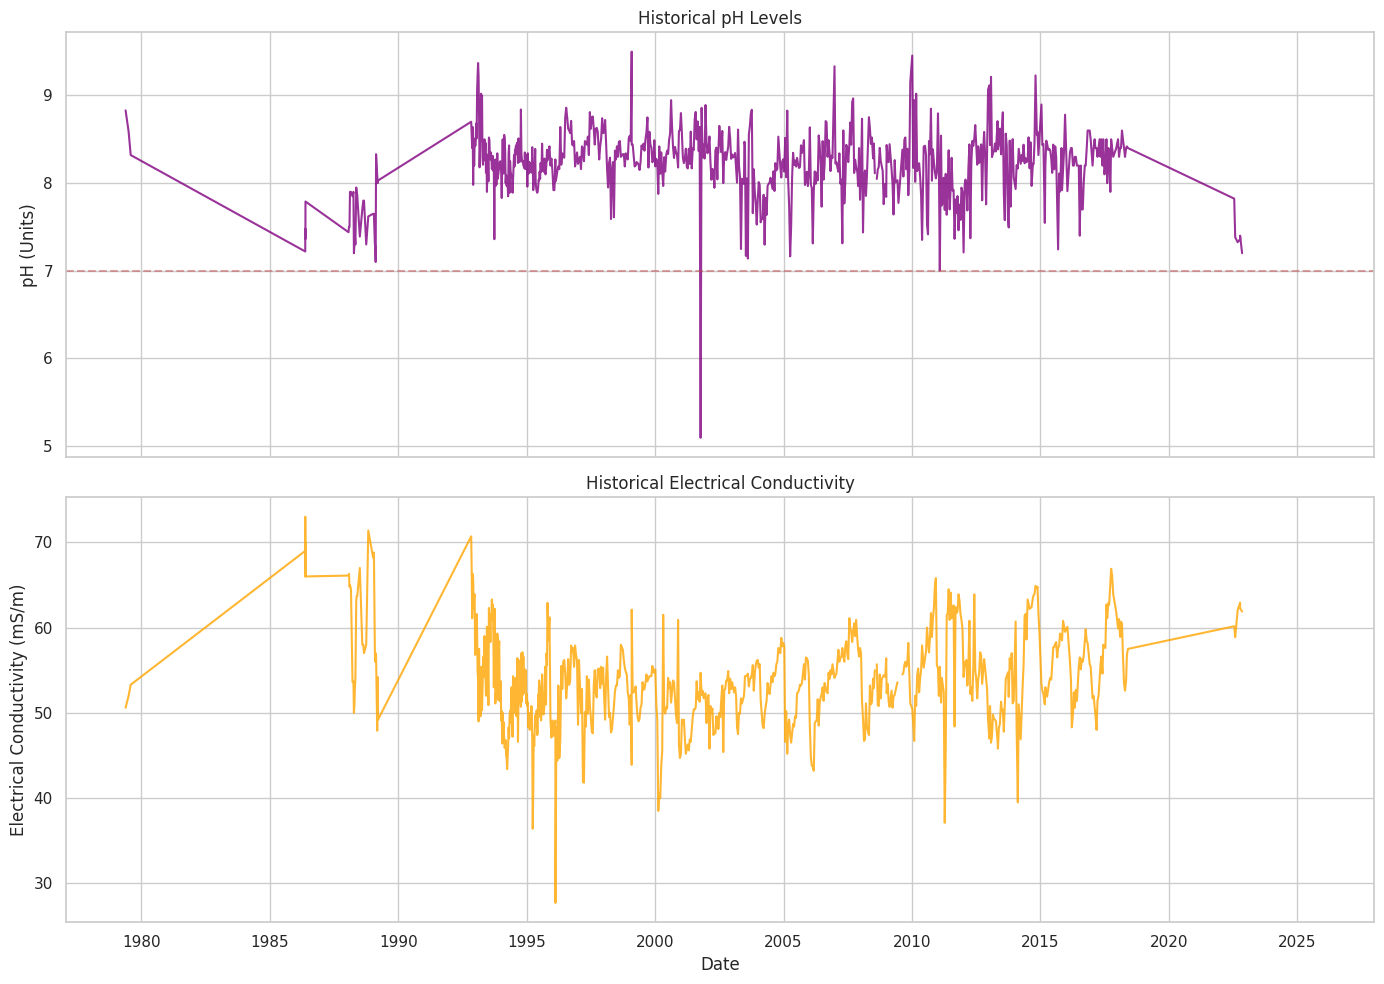

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(df['date_time'], df['pH_Diss_Water'], color='purple', alpha=0.8)
ax1.set_ylabel('pH (Units)')
ax1.set_title('Historical pH Levels')
ax1.axhline(y=7, color='r', linestyle='--', alpha=0.5) # Add a neutral pH reference line

ax2.plot(df['date_time'], df['EC_Phys_Water'], color='orange', alpha=0.8)
ax2.set_ylabel('Electrical Conductivity (mS/m)')
ax2.set_xlabel('Date')
ax2.set_title('Historical Electrical Conductivity')

fig.tight_layout()
plt.show()

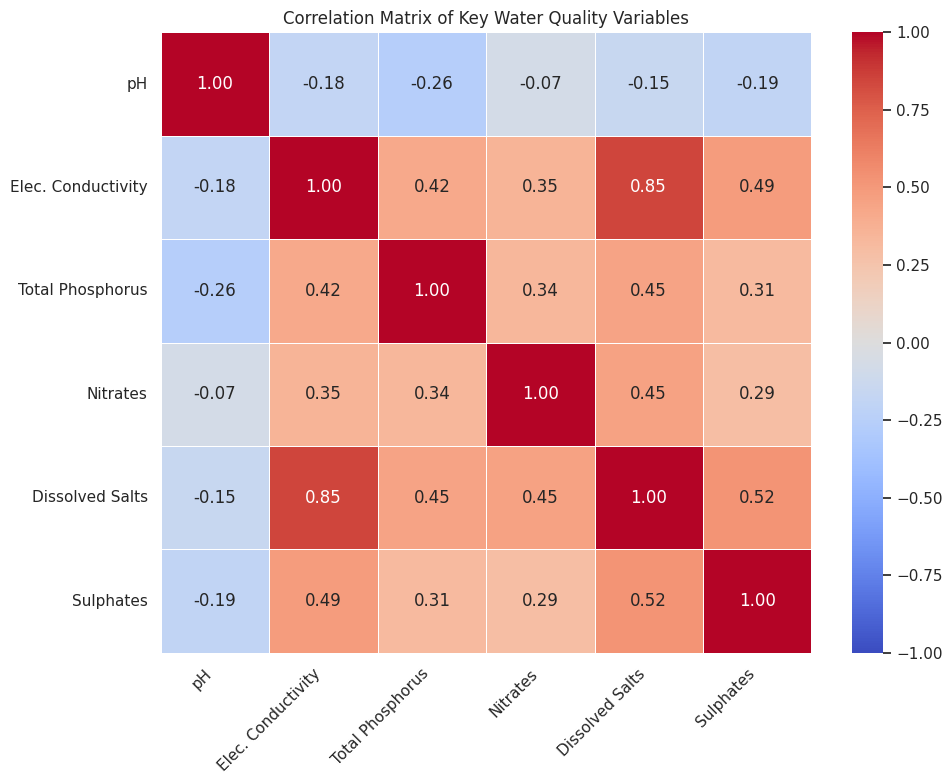

In [7]:
key_vars = [
    'pH_Diss_Water', 'EC_Phys_Water', 'P_Tot_Water', 
    'NO3_NO2_N_Diss_Water', 'DMS_Tot_Water', 'SO4_Diss_Water'
]

nice_names = ['pH', 'Elec. Conductivity', 'Total Phosphorus', 'Nitrates', 'Dissolved Salts', 'Sulphates']
corr_data = df[key_vars].rename(columns=dict(zip(key_vars, nice_names)))

corr_matrix = corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Key Water Quality Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()